#Issue 1: Optimizing Hyperparameters

##Technical Section
This section will include detailed, quantitative, and algorithmic aspects of hyperparameter optimization:

### 1.Introduction to Hyperparameter Optimization

Hyperparameters play a crucial role in determining how a model learns from data. Properly optimizing these hyperparameters can significantly enhance model performance. Here, we will explore common hyperparameters, methods for optimizing them, and evaluating their significance.

### 2.Common Hyperparameters (Technical Detail)

 A list of common hyperparameters, their roles, and the effects they have on model training:

**Learning Rate**: Controls how much to adjust the model parameters in response to the estimated error.

**Number of Trees**: In ensemble methods like Random Forest, this hyperparameter regulates the complexity.

**Maximum Depth**: Limits how deep the tree can grow and thus controls overfitting.

**Batch Size**: The number of training examples utilized in one iteration of model training.

###3.Methods for Hyperparameter Optimization

Here are three common approaches for hyperparameter optimization with example code:

### 3.1. Grid Search Implementation:

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define model and parameters to optimize
model = RandomForestClassifier()
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Perform grid search
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Best parameters from Grid Search:", best_params)

NameError: name 'RandomForestClassifier' is not defined

### 3.2. Random Search Implementation:

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Random search with specified distributions
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=100, scoring='accuracy', cv=5)
random_search.fit(X_train, y_train)
best_params = random_search.best_params_
print("Best parameters from Random Search:", best_params)

###3.3. Bayesian Optimization Overview:
Bayesian optimization uses probabilistic models to find the best hyperparameters efficiently:

In [ ]:
from skopt import BayesSearchCV

# Define the Bayesian search
opt = BayesSearchCV(
    model,
    {'n_estimators': (50, 200), 'max_depth': (1, 30)},
    n_iter=50
)
opt.fit(X_train, y_train)
best_params = opt.best_params_
print("Best parameters from Bayesian Optimization:", best_params)

### 4. Evaluating Hyperparameter Performance

Once hyperparameters are set, it’s essential to evaluate the model's performance using techniques such as cross-validation:

4.1 K-Fold Cross-Validation: An example implementation using scikit-learn:

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross-Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Various metrics can be computed to evaluate model performance.
**Accuracy**: The proportion of correct predictions.

**F1 Score**: The harmonic mean of precision and recall, useful for imbalanced datasets.

#Issue 3: Applying Ensemble Learning—Bagging, Boosting, or Stacking

In [ ]:
import numpy as np
import yfinance as yf

df = yf.download("IVV", start="2000-01-01", end="2022-01-01")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


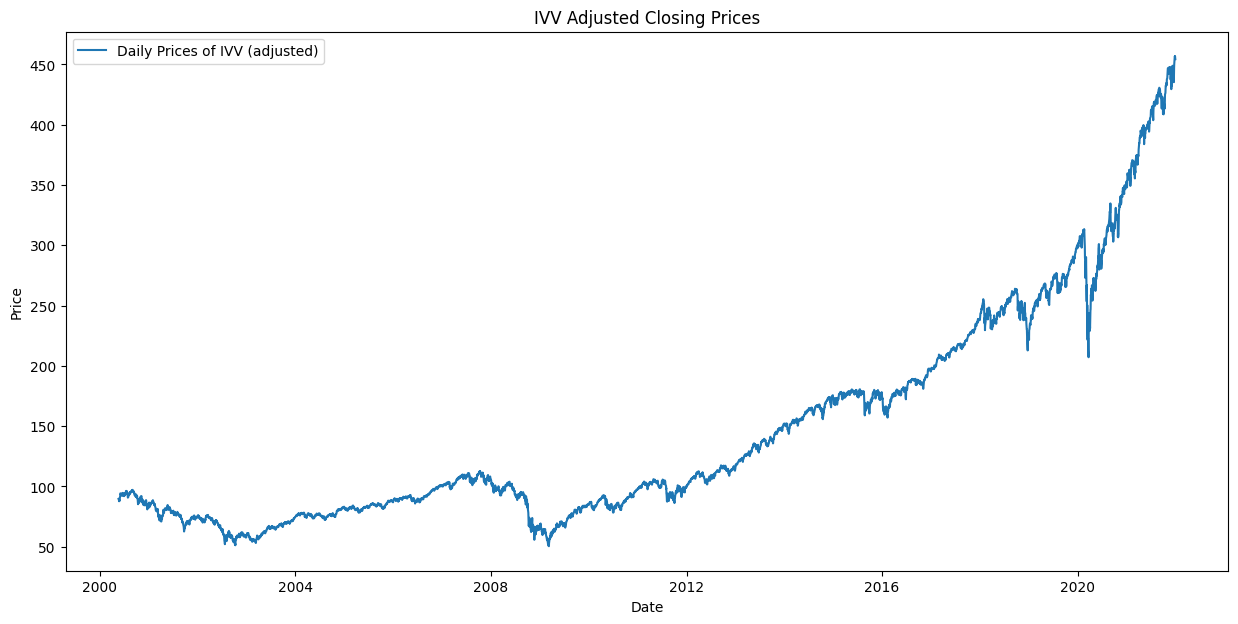

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df.index, df["Close"], label="Daily Prices of IVV (adjusted)")
plt.title("IVV Adjusted Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

df = yf.download("IVV", start="2000-01-01", end="2022-01-01", auto_adjust=True, progress=False)

df["Ret"] = df["Close"].pct_change()

name = "Ret"
df["Ret10_i"] = (
    df[name].rolling(10).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 10) - 1))
)
df["Ret25_i"] = (
    df[name].rolling(25).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 25) - 1))
)
df["Ret60_i"] = (
    df[name].rolling(60).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 60) - 1))
)
df["Ret120_i"] = (
    df[name].rolling(120).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 120) - 1))
)
df["Ret240_i"] = (
    df[name].rolling(240).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 240) - 1))
)

df.drop(columns=["Open", "High", "Low", "Volume", "Close"], inplace=True)

df = df.dropna()

print(df.tail(10))

Price            Ret   Ret10_i   Ret25_i   Ret60_i  Ret120_i  Ret240_i
Ticker                                                                
Date                                                                  
2021-12-17 -0.009920  0.183887 -0.018515  0.068618  0.066739  0.092679
2021-12-20 -0.011231 -0.048900 -0.093004  0.046588  0.056584  0.081841
2021-12-21  0.017815 -0.077937 -0.023435  0.081283  0.066608  0.086833
2021-12-22  0.010085 -0.003962  0.000791  0.131668  0.068654  0.093751
2021-12-23  0.006131  0.124921  0.034681  0.138996  0.075878  0.096234
2021-12-27  0.014324  0.171785  0.078427  0.183533  0.084331  0.101114
2021-12-28 -0.000772  0.253160  0.081878  0.162481  0.090404  0.102239
2021-12-29  0.001044  0.334736  0.098062  0.186041  0.082457  0.105694
2021-12-30 -0.002815  0.150129  0.081235  0.163925  0.077023  0.101268
2021-12-31 -0.002488  0.217468  0.060886  0.152679  0.077875  0.094529


In [ ]:
df = yf.download("IVV", start="2000-01-01", end="2022-01-01", auto_adjust=True, progress=False)

df["Ret"] = df["Close"].pct_change()

name = "Ret"
df["Ret10_i"] = df[name].rolling(10).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 10) - 1))
df["Ret25_i"] = df[name].rolling(25).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 25) - 1))
df["Ret60_i"] = df[name].rolling(60).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 60) - 1))
df["Ret120_i"] = df[name].rolling(120).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 120) - 1))
df["Ret240_i"] = df[name].rolling(240).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 240) - 1))

df["Ret25"] = df["Ret25_i"].shift(-25)

df.drop(columns=["Open", "High", "Low", "Volume", "Close"], inplace=True)

df = df.dropna()

print(df.tail(10))

Price            Ret   Ret10_i   Ret25_i   Ret60_i  Ret120_i  Ret240_i  \
Ticker                                                                   
Date                                                                     
2021-11-11  0.000408  0.121260  0.225124  0.096783  0.090221  0.109549   
2021-11-12  0.007365  0.175830  0.260471  0.106569  0.098148  0.108042   
2021-11-15  0.000256  0.157771  0.291536  0.093756  0.096833  0.107264   
2021-11-16  0.003985  0.158219  0.317620  0.085918  0.099714  0.109002   
2021-11-17 -0.002356  0.073268  0.293892  0.079090  0.096162  0.104452   
2021-11-18  0.003298  0.060422  0.238995  0.081100  0.099561  0.106602   
2021-11-19 -0.001633  0.008923  0.201792  0.088244  0.096814  0.104762   
2021-11-22 -0.002995 -0.031474  0.178152  0.068644  0.097500  0.107176   
2021-11-23  0.001385  0.017250  0.152318  0.063555  0.091090  0.107980   
2021-11-24  0.002595  0.122620  0.147328  0.069678  0.093960  0.109583   

Price          Ret25  
Ticker        

# Issue 2: Optimizing the Bias-Variance Tradeoff

In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import validation_curve

data = yf.download('AAPL', start='2018-01-01', end='2024-01-01')
data['Target'] = data['Close'].shift(-1)
data.dropna(inplace=True)  # Drop rows with NaN

X = data[['Close', 'Volume']].values  # Features
y = data['Target'].values  # Target: Next day's Close

# Initialize model
model = DecisionTreeRegressor()

# Perform cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

# Calculate average MSE
average_mse = -scores.mean()
print(f'Average MSE: {average_mse}')

[*********************100%***********************]  1 of 1 completed

Average MSE: 39.84998569077429


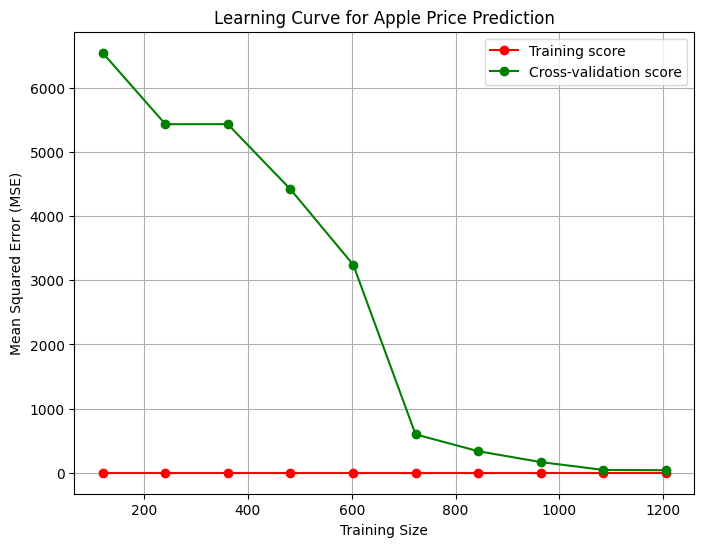

In [ ]:
# Generate learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate mean and standard deviation
train_scores_mean = -train_scores.mean(axis=1)  # Convert negative to positive MSE
test_scores_mean = -test_scores.mean(axis=1)

# Plot learning curves
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.title('Learning Curve for Apple Price Prediction')
plt.xlabel('Training Size')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend(loc="best")
plt.grid()
plt.show()

## Optimization

# Regularization Methods

In [ ]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit Ridge and Lasso models with different alphas
alphas = np.logspace(-6, 1, 8)
ridge_scores = []
lasso_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    lasso = Lasso(alpha=alpha)

    ridge.fit(X_train, y_train)
    lasso.fit(X_train, y_train)

    ridge_pred = ridge.predict(X_test)
    lasso_pred = lasso.predict(X_test)

    ridge_mse = mean_squared_error(y_test, ridge_pred)
    lasso_mse = mean_squared_error(y_test, lasso_pred)

    ridge_scores.append(ridge_mse)
    lasso_scores.append(lasso_mse)

# Display results
print("Ridge MSE:", ridge_scores)
print("Lasso MSE:", lasso_scores)


Ridge MSE: [5.791731481497488, 5.791731481471206, 5.791731481208403, 5.7917314785803375, 5.791731452299787, 5.791731189497116, 5.791728561759454, 5.791702313292232]
Lasso MSE: [5.791731476954698, 5.791731441488807, 5.7917310246970715, 5.791727470770416, 5.7916857233485715, 5.791338716707137, 5.788626224342662, 5.80345282761357]


# Model Complexity Management

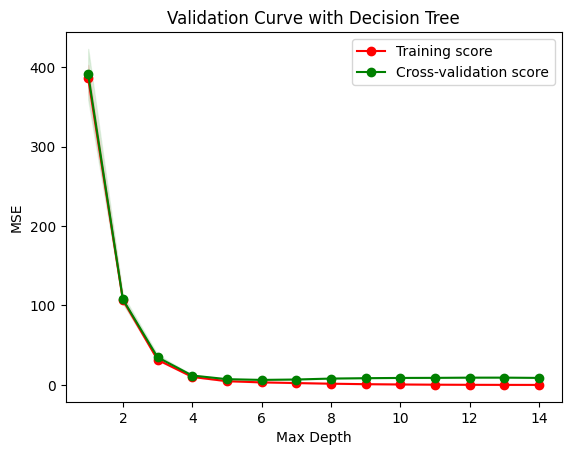

In [ ]:
# Initialize model
model = DecisionTreeRegressor()

# Define parameter range
param_range = np.arange(1, 15)  # Max depths from 1 to 14

# Calculate validation curve
train_scores, test_scores = validation_curve(model, X_train, y_train, param_name="max_depth", param_range=param_range, cv=3, scoring="neg_mean_squared_error")

# Calculate mean and standard deviation for training set scores
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)

# Calculate mean and standard deviation for test set scores
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot validation curve
plt.fill_between(param_range, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(param_range, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(param_range, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(param_range, test_scores_mean, 'o-', color="g", label="Cross-validation score")

plt.title("Validation Curve with Decision Tree")
plt.xlabel("Max Depth")
plt.ylabel("MSE")
plt.legend(loc="best")
plt.show()